# Epic of Sun - Desafio 1
Training  the model.
***

This jupyter notebook trains a UNet for sugarcane identification from satellite images.

It is divided in 5 parts:
* Loading libraries and data
* Separating the datasets in training and validation
* Build the model
* Train the model
* Evaluate the training

***

## Loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import random
import math

#import geopandas as gpd
#import rasterio
#from rasterio.features import rasterize

import json
#import joblib
from pathlib import Path
#import os

import tensorflow as tf
#from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

#import keras_tuner as kt

"""from sklearn.metrics import (
	classification_report, 
	confusion_matrix, 
	roc_auc_score,
	roc_curve,
	precision_recall_curve, 
    precision_score,
    recall_score,
    f1_score,
	recall_score)"""

2026-08-11 18:36:51.971880: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786484212.832944   53110 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786484213.027295   53110 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-11 18:36:55.060669: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# Flags
flag_load_hyperparams = False

In [3]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [4]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

# Specify the path to the TFRecords directory
tfrecord_path = base_path / "data" / "tfrecords"

In [5]:
patch_index = pd.read_csv(patches_path / "patch_index.csv")

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene01         0          0          0   
1  scene01         1          0         64   
2  scene01         2          0        128   
3  scene01         3          0        192   
4  scene01         4          0        256   

                                   x_patch_path  \
0  data/processed/scene01/images/patch_0000.npy   
1  data/processed/scene01/images/patch_0001.npy   
2  data/processed/scene01/images/patch_0002.npy   
3  data/processed/scene01/images/patch_0003.npy   
4  data/processed/scene01/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene01/masks/patch_0000.npy              8434  
1  data/processed/scene01/masks/patch_0001.npy             12836  
2  data/processed/scene01/masks/patch_0002.npy              9355  
3  data/processed/scene01/masks/patch_0003.npy              3983  
4  data/processed/scene01/masks/patch_0004.npy               805  
44890


## Selecting datasets in training and validation

In [6]:
# Function to add spectral indices to the input patches

def add_spectral_indices(X_data, eps=1e-8):
    """
    Appends spectral indices (NDVI, NDWI, EVI) as extra channels to input patches.
    
    Expected input shape: (..., H, W, 4) or (H, W, 4)
    Channels: [Blue (0), Green (1), Red (2), NIR (3)]
    """
    # Extract individual bands along the last axis
    blue  = X_data[..., 0]
    green = X_data[..., 1]
    red   = X_data[..., 2]
    nir   = X_data[..., 3]

    # 1. NDVI: (NIR - Red) / (NIR + Red)
    ndvi = (nir - red) / (nir + red + eps)

    # 2. NDWI: (Green - NIR) / (Green + NIR)
    ndwi = (green - nir) / (green + nir + eps)

    # 3. EVI: 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)

    # Re-add channel dimension to calculated 2D indices
    ndvi = np.expand_dims(ndvi, axis=-1)
    ndwi = np.expand_dims(ndwi, axis=-1)
    evi  = np.expand_dims(evi, axis=-1)

    # Stack original bands with new index channels along the channel axis
    X_expanded = np.concatenate([X_data, ndvi, ndwi, evi], axis=-1)

    return X_expanded

In [7]:
# Load the best hyperparameters from the JSON file
if flag_load_hyperparams:
	json_path = base_path / "models" / "best_sugarcane_params.json"

	with open(json_path, "r") as f:
		saved_params = json.load(f)
	print("Loaded hyperparameters from JSON:")
	print(saved_params)
else:
	saved_params = {
		"init_filters": 32,
		"batch_size": 64,
		"lr": 0.0001
	}
	print("Hyperparameters not loaded from JSON. Using default values:")
	print(saved_params)

Hyperparameters not loaded from JSON. Using default values:
{'init_filters': 32, 'batch_size': 64, 'lr': 0.0001}


In [8]:
# Load the count JSON file
with open(tfrecord_path / "counts.json") as f:
    counts = json.load(f)

n_train, n_val, n_test = counts["train"], counts["val"], counts["test"]

In [9]:
# Functions to create TensorFlow datasets for training, validation, and testing

def _parse_example(example_proto):
    feature_description = {
        "x": tf.io.FixedLenFeature([], tf.string),
        "y": tf.io.FixedLenFeature([], tf.string),
        "scene": tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    x = tf.io.parse_tensor(parsed["x"], out_type=tf.float32)
    y = tf.io.parse_tensor(parsed["y"], out_type=tf.float32)
    x.set_shape((128, 128, 4))
    y.set_shape((128, 128, 1))
    scene = parsed["scene"]
    return x, y, scene

def _augment(x, y, scene):
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_left_right(x); y = tf.image.flip_left_right(y)
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_up_down(x); y = tf.image.flip_up_down(y)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k); y = tf.image.rot90(y, k)
    factor = tf.random.uniform((), 0.9, 1.1)
    x = tf.clip_by_value(x * factor, 0.0, 1.0)
    return x, y, scene

def _add_indices(x, y, scene):
    blue, green, red, nir = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    eps = 1e-8
    ndvi = (nir - red) / (nir + red + eps)
    ndwi = (green - nir) / (green + nir + eps)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)
    x = tf.stack([blue, green, red, nir, ndvi, ndwi, evi], axis=-1)
    return x, y, scene

def _drop_scene(x, y, scene):
    return x, y

def make_tfrecord_dataset(prefix, batch_size, num_patches, shuffle=True,
                           augment=True, compute_indices=True, keep_scene=False):
    file_pattern = str(tfrecord_path / f"{prefix}_*.tfrecord")
    files = tf.data.Dataset.list_files(file_pattern, shuffle=shuffle)

    ds = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    # Use this one line instead of the next one to avoid the error "ValueError: 
    # num_parallel_calls must be a tf.int32 scalar tensor or None."
    ds = ds.map(_parse_example, num_parallel_calls=tf.data.AUTOTUNE)
    # Use this line to avoid overheading the CPU with too many parallel calls, 
    # which can lead to the error "ValueError: num_parallel_calls must be a 
    # tf.int32 scalar tensor or None."
    #ds = ds.map(_parse_example, num_parallel_calls=2)  # instead of AUTOTUNE

    if shuffle:
        ds = ds.shuffle(buffer_size=2000)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    if compute_indices:
        ds = ds.map(_add_indices, num_parallel_calls=tf.data.AUTOTUNE)

    # Drop the scene string BEFORE batching, not after -- keeps the batched
    # element structure as plain (x, y), which is what model.fit() expects.
    # Do this before .batch() rather than after, since batching a dropped
    # scalar string alongside numeric tensors is exactly what caused the
    # XLA_GPU_JIT error you hit.
    if not keep_scene:
        ds = ds.map(_drop_scene, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    num_batches = math.ceil(num_patches / batch_size)
    ds = ds.apply(tf.data.experimental.assert_cardinality(num_batches))

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [10]:
# Create TensorFlow datasets for training, validation, and testing
# Only train and validation is goingto be used in this notebook, so no test dataset is created.
train_ds = make_tfrecord_dataset("train", saved_params["batch_size"], n_train, shuffle=True, augment=True)
val_ds   = make_tfrecord_dataset("val",   saved_params["batch_size"], n_val,   shuffle=False, augment=True)
#test_ds  = make_tfrecord_dataset("test",  saved_params["batch_size"], n_test,  shuffle=False, augment=False)

I0000 00:00:1786484253.510525   53110 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [11]:
# Show the number of batches in training, validation, and testing sets
# Taken form the counts.json file, which is generated during the TFRecord creation process
print("Training batches:", n_train)
print("Validation batches:", n_val)
#print("Testing batches:", n_test)

Training batches: 26934
Validation batches: 8978
Testing batches: 8978


In [12]:
# Get a sample batch from the training generator to inspect its shape and data type
X_batch, y_batch = next(iter(train_ds))

print("Training batch shape:", X_batch.shape)
print("Training label shape:", y_batch.shape)
print("Training batch data type:", X_batch.dtype)
print("Training label data type:", y_batch.dtype)

2026-08-11 18:37:44.426309: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:370] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-08-11 18:37:56.183724: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 463 of 2000
2026-08-11 18:38:06.243566: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 1360 of 2000
2026-08-11 18:38:08.197581: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Training batch shape: (64, 128, 128, 7)
Training label shape: (64, 128, 128, 1)
Training batch data type: <dtype: 'float32'>
Training label data type: <dtype: 'float32'>


## Build the Model

In [13]:
# Loss functions

# Binary cross-entropy treats every pixel independently and doesn't "know" about overlap; 
# Dice loss directly optimizes for segmentation overlap, which is exactly what IoU measures, 
# and it tends to push recall up for the minority-in-that-image foreground class without 
# hurting precision much.

@tf.keras.utils.register_keras_serializable()
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

@tf.keras.utils.register_keras_serializable()
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

@tf.keras.utils.register_keras_serializable()
def combined_loss(alpha=0.5):
    """
    alpha: weight on BCE component. (1-alpha) weight on Dice.
    alpha=1.0 -> pure BCE (your original, precision-favoring setup)
    alpha=0.0 -> pure Dice (recall/overlap-favoring, likely what you just ran)
    alpha=0.5 -> balanced mix
    """
    def loss_fn(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        bce = tf.reduce_mean(bce)

        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])
        smooth = 1e-6
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        dice = 1 - (2. * intersection + smooth) / (
            tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
        )

        return alpha * bce + (1 - alpha) * dice
    return loss_fn

In [14]:
"""
# Convolution block
# Each block performs Conv -> ReLU -> Conv -> ReLU

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x
"""

'\n# Convolution block\n# Each block performs Conv -> ReLU -> Conv -> ReLU\n\ndef conv_block(inputs, filters):\n\n    x = layers.Conv2D(\n        filters,\n        3,\n        padding="same",\n        activation="relu"\n    )(inputs)\n\n    x = layers.Conv2D(\n        filters,\n        3,\n        padding="same",\n        activation="relu"\n    )(x)\n\n    return x\n'

In [15]:
# Convolution block
# Each block performs 
# Conv -> BatchNormalization -> ReLU -> Conv -> BatchNormalization -> ReLU

def conv_block(inputs, filters, dropout=0.0):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    return x

In [16]:
# Encoder block
# Each block performs:
#  extracts features
#  saves them for the skip connection
#  downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [17]:
# Decoder block
# Each block performs:
#  upsamples
#  concatenates the skip connection
#  performs two convolutions

def decoder_block(inputs, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)
	
    x = layers.Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

In [18]:
"""
# Function to build the network, compile it, use tunned hyperparameters, and return the model

def build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)  # 32
    s2, p2 = encoder_block(p1, init_filters * 2)  # 64
    s3, p3 = encoder_block(p2, init_filters * 4)  # 128
    s4, p4 = encoder_block(p3, init_filters * 8)  # 256
    
    # Bottleneck
    b1 = conv_block(p4, init_filters * 16)        # 512
    
    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)  # 256
    d2 = decoder_block(d1, s3, init_filters * 4)  # 128
    d3 = decoder_block(d2, s2, init_filters * 2)  # 64
    d4 = decoder_block(d3, s1, init_filters)      # 32
    
    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)
    
    # Unified comilation with the original metrics
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
			learning_rate=lr, 
			weight_decay=1e-4
		),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )
    return model
"""

'\n# Function to build the network, compile it, use tunned hyperparameters, and return the model\n\ndef build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):\n    inputs = layers.Input(input_shape)\n    \n    # Encoder\n    s1, p1 = encoder_block(inputs, init_filters)  # 32\n    s2, p2 = encoder_block(p1, init_filters * 2)  # 64\n    s3, p3 = encoder_block(p2, init_filters * 4)  # 128\n    s4, p4 = encoder_block(p3, init_filters * 8)  # 256\n    \n    # Bottleneck\n    b1 = conv_block(p4, init_filters * 16)        # 512\n    \n    # Decoder\n    d1 = decoder_block(b1, s4, init_filters * 8)  # 256\n    d2 = decoder_block(d1, s3, init_filters * 4)  # 128\n    d3 = decoder_block(d2, s2, init_filters * 2)  # 64\n    d4 = decoder_block(d3, s1, init_filters)      # 32\n    \n    # Output\n    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)\n    model = Model(inputs, outputs)\n    \n    # Unified comilation with the original metrics\n    model.compile(\n        optimizer=tf.k

In [19]:
# Function to build the network, compile it, use tunned hyperparameters, and return the model

def build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)        # 32
    s2, p2 = encoder_block(p1, init_filters * 2)        # 64
    s3, p3 = encoder_block(p2, init_filters * 4)        # 128
    s4, p4 = encoder_block(p3, init_filters * 8)        # 256
    
    # Bottleneck
    b1 = conv_block(p4, init_filters * 16, dropout=0.3) # 512
    
    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)        # 256
    d2 = decoder_block(d1, s3, init_filters * 4)        # 128
    d3 = decoder_block(d2, s2, init_filters * 2)        # 64
    d4 = decoder_block(d3, s1, init_filters)            # 32
    
    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)
    
    # Unified comilation with the original metrics
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        #loss=bce_dice_loss,
		loss=combined_loss(alpha=0.7),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
        ]
    )
    return model

In [20]:
# Create the model with the best hyperparameters
model = build_unet(
    init_filters=saved_params["init_filters"], 
    lr=saved_params["lr"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,016 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,728 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 7,770,081 (29.64 MB)

 Trainable params: 7,764,193 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

## Train the model

In [22]:
# Checkpoint callback to save the best model based on validation loss
model_path = base_path / "models" / "unet_sugarcane.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [23]:
# Checkpoint callback to stop training early if the validation loss does not improve for a certain number of epochs (patience)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [24]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    verbose=1
)

In [25]:
# Train the model
print("Training a new model.")
history = model.fit(
	train_ds,
	validation_data=val_ds,
	epochs=50,
	callbacks=[checkpoint, early_stop, reduce_lr],
	verbose=1
)
history_dict = history.history
print("Training completed.")

Model loaded, skipping training.


In [26]:
# Save the model and its history for future use.

# Save the model in the Keras format (.keras) which includes both architecture and weights.
model_path = base_path / "models" / "unet_sugarcane.keras"
model.save(str(model_path))
print(f"Model saved to '{model_path}'")

# Save the training history as a JSON file for future reference.
history_path = base_path / "models" / "training_history.json"
with open(str(history_path), 'w') as f:
	json.dump(history_dict, f)
print(f"Training history saved to '{history_path}'")


Skipping saving model and history.


## Evaluate the training


Visualization saved as '/home/fdesmello/Git/spacesugar2/figures/loss_accuracy.png'


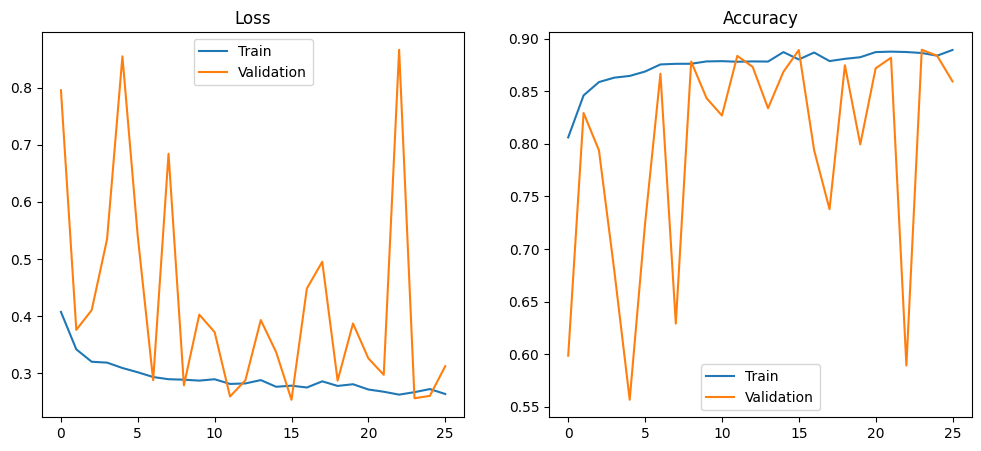

In [27]:
# Plot the learning curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train")
plt.plot(history_dict["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dict["binary_accuracy"], label="Train")
plt.plot(history_dict["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / "loss_accuracy.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()